# 04 — Embeddings, anomaly detection and the comparison

Reads the artefacts produced by the pipeline; it does not retrain anything.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # run from notebooks/
%matplotlib inline

In [2]:
from evaluation.visualization import load_embeddings
d = load_embeddings()
print("embeddings:", d["embeddings"].shape)
import collections; print(collections.Counter(d["split"].astype(str)))

embeddings: (5066, 128)
Counter({np.str_('train'): 2554, np.str_('val'): 1274, np.str_('test'): 1238})


In [3]:
import json
edr = json.load(open("../results/metrics/anomaly_detection.json"))
print("EDR threshold:", round(edr["edr_threshold_nats_per_s"], 3), "nats/s")
print("healthy windows flagged:", edr["timeline"]["windows_flagged_before_switch"],
      "/", edr["timeline"]["windows_total_before_switch"])
print("faulty windows flagged :", edr["timeline"]["windows_flagged_after_switch"],
      "/", edr["timeline"]["windows_total_after_switch"])
print("segment ROC-AUC:", round(edr["segment_level"]["roc_auc_fault_vs_healthy"], 3))

EDR threshold: 1.754 nats/s
healthy windows flagged: 0 / 10
faulty windows flagged : 18 / 18
segment ROC-AUC: 1.0


The healthy baseline is fitted on a *chronological* commissioning portion of each
Normal recording, not on a record-level split: CWRU has one Normal recording per
motor load, so a record split makes the detector call unseen healthy loads faulty.

In [4]:
import pandas as pd
df = pd.read_csv("../results/metrics/comparison.csv")
df.pivot_table(index="label_fraction", columns="method", values="f1_macro_mean").round(3)

method,SSL + mlp,SSL + svm_rbf,Supervised CNN (baseline)
label_fraction,,,
0.01,0.590,0.592,0.788
0.05,0.630,0.618,0.855
0.10,0.650,0.674,0.849
0.20,0.651,0.656,0.861


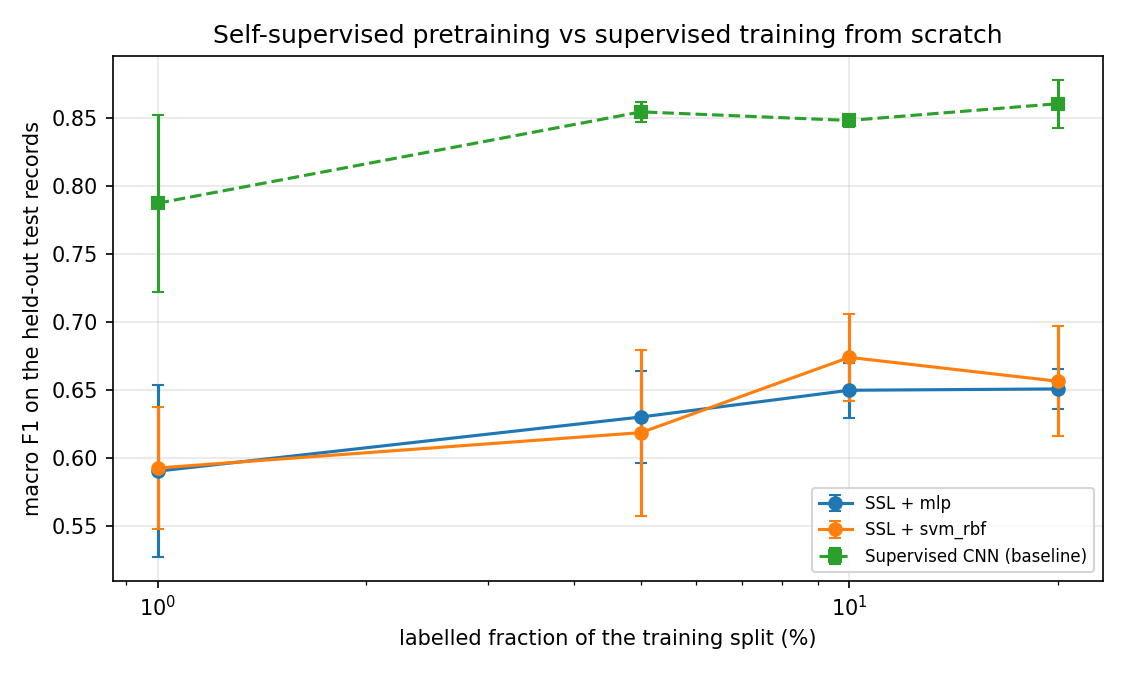

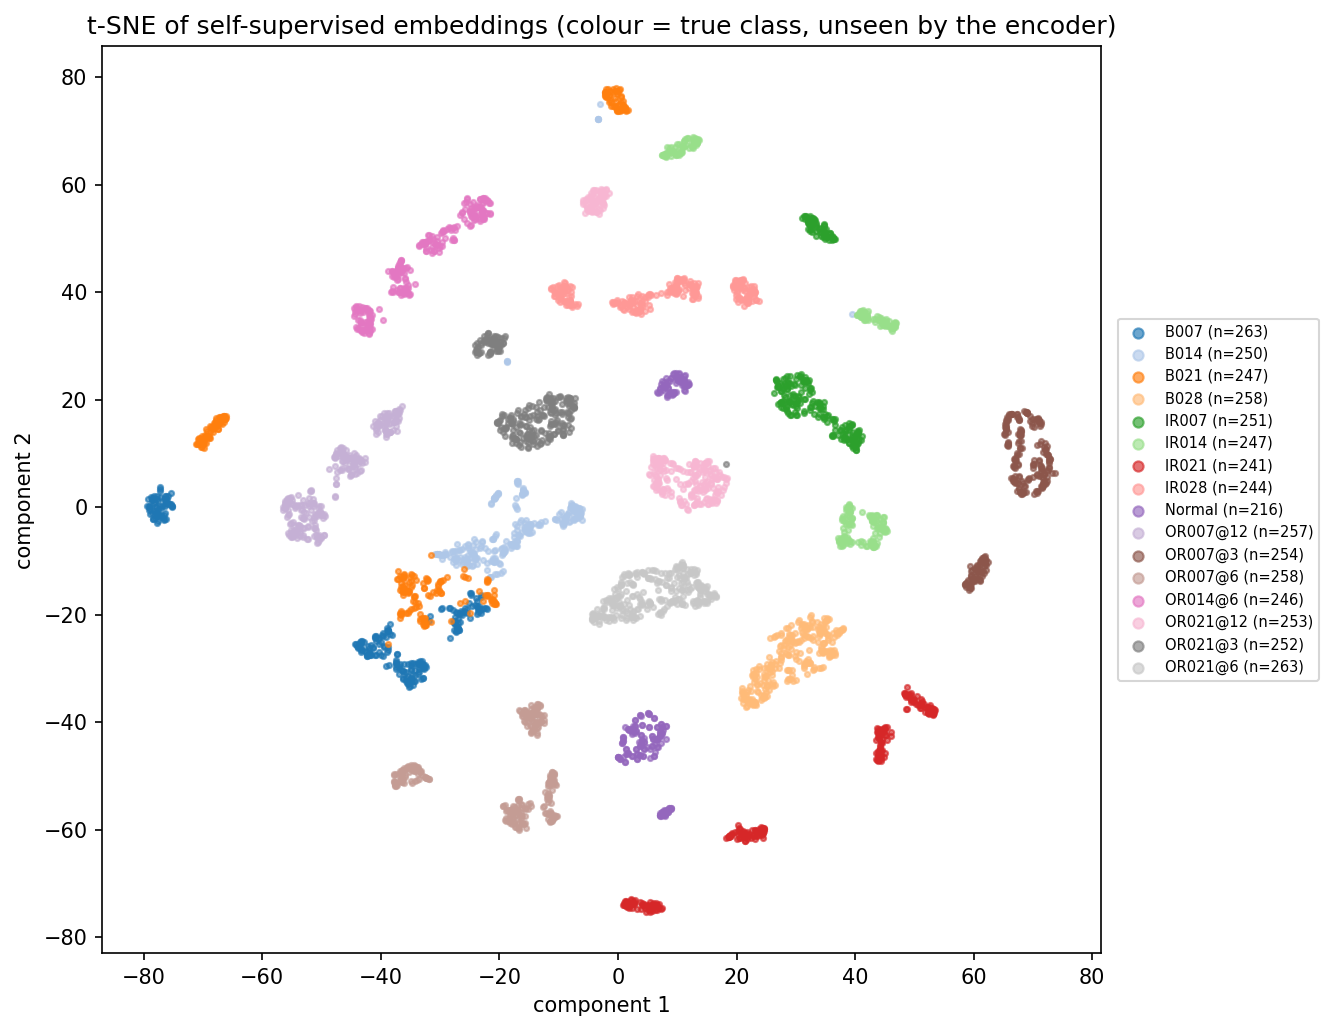

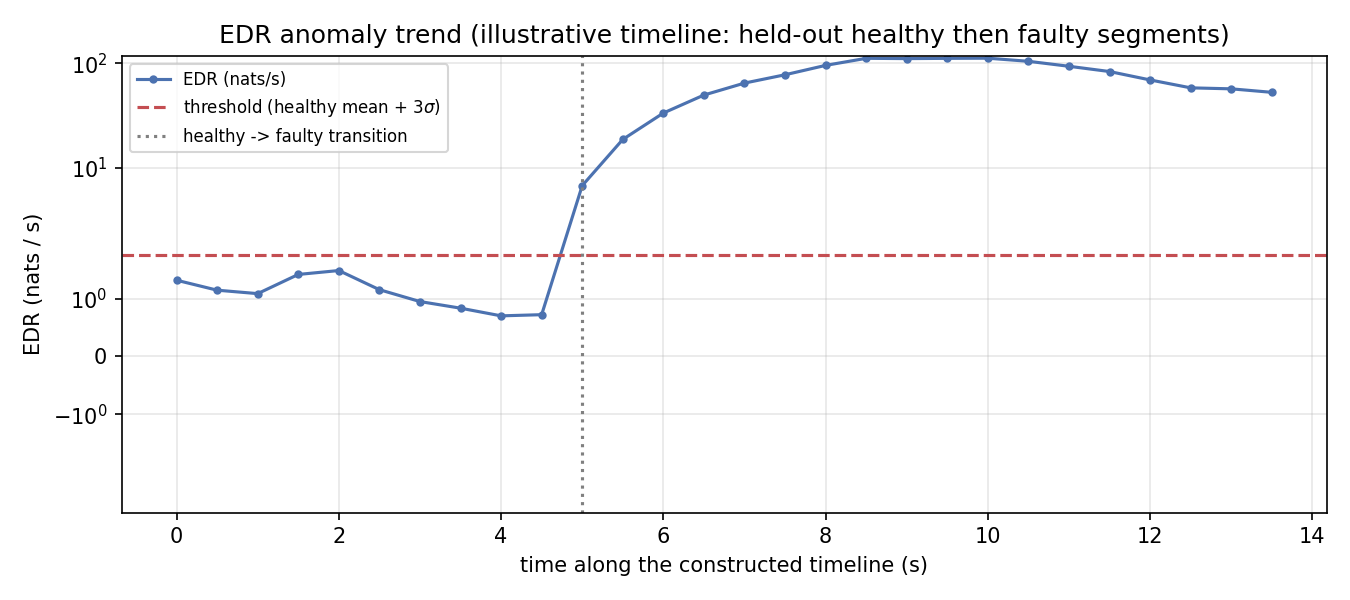

In [5]:
from IPython.display import Image, display
for f in ["12_ssl_vs_baseline.png", "05_tsne_embeddings.png", "07_edr_trend.png"]:
    display(Image(filename=f"../results/figures/{f}"))